In [19]:
!pip install --user --no-cache-dir camb

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 41.8 MB/s eta 0:00:00a 0:00:01
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.


# Set 05 — AI-Driven High Energy Physics

Completed assignment solutions.

# Exercise 01

We want to show that

$$
\hat{\sigma}^2=\frac{\mathrm{RSS}(\hat{\beta})}{N-p}
$$

is an unbiased estimator of $\sigma^2$ for the linear model

$$
Y=X\beta+\varepsilon,\qquad \varepsilon\sim\mathcal{N}(0,\sigma^2 I).
$$

At the least-squares solution,

$$
\hat Y=HY,\qquad H=X(X^\top X)^{-1}X^\top,
$$

where $H$ is the hat matrix. The residual vector is

$$
e=Y-\hat Y=(I-H)Y=(I-H)\varepsilon,
$$

because $(I-H)X\beta=0$. Therefore

$$
\mathrm{RSS}(\hat\beta)=e^\top e
=\varepsilon^\top(I-H)\varepsilon.
$$

Using $E[\varepsilon\varepsilon^\top]=\sigma^2 I$,

$$
E[\mathrm{RSS}]
=\sigma^2\mathrm{tr}(I-H).
$$

For a full-rank design matrix, $\mathrm{tr}(H)=p$, so

$$
E[\mathrm{RSS}]=\sigma^2(N-p).
$$

Hence

$$
E\left[\frac{\mathrm{RSS}(\hat\beta)}{N-p}\right]=\sigma^2.
$$

Therefore $\hat{\sigma}^2$ is unbiased.

In [1]:
# Numerical check of the unbiasedness result
import numpy as np

rng = np.random.default_rng(42)

N = 100
p = 3
sigma_true = 2.0
n_trials = 5000

X = rng.normal(size=(N, p))
beta_true = np.array([1.0, -2.0, 0.5])

sigma2_estimates = []

for _ in range(n_trials):
    eps = rng.normal(0.0, sigma_true, size=N)
    Y = X @ beta_true + eps

    beta_hat = np.linalg.lstsq(X, Y, rcond=None)[0]
    residuals = Y - X @ beta_hat
    rss = residuals @ residuals

    sigma2_estimates.append(rss / (N - p))

print("True sigma^2:", sigma_true**2)
print("Mean estimated sigma^2:", np.mean(sigma2_estimates))

True sigma^2: 4.0
Mean estimated sigma^2: 4.006407570786123


# Exercise 02

Starting from the generalized residual sum of squares

$$
\mathrm{RSS}_\Sigma(\beta)
=e^\top\Sigma^{-1}e
=(Y-X\beta)^\top\Sigma^{-1}(Y-X\beta),
$$

the Gaussian likelihood for correlated errors is proportional to

$$
L(\beta)\propto
\exp\left[
-\frac12(Y-X\beta)^\top\Sigma^{-1}(Y-X\beta)
\right].
$$

Maximizing the likelihood is therefore equivalent to minimizing $\mathrm{RSS}_\Sigma(\beta)$.

Differentiate with respect to $\beta$:

$$
\frac{\partial \mathrm{RSS}_\Sigma}{\partial\beta}
=
-2X^\top\Sigma^{-1}(Y-X\beta).
$$

Setting the derivative to zero gives

$$
X^\top\Sigma^{-1}Y
=
X^\top\Sigma^{-1}X\hat\beta.
$$

Assuming $X^\top\Sigma^{-1}X$ is invertible,

$$
\boxed{
\hat{\beta}
=
(X^\top\Sigma^{-1}X)^{-1}
X^\top\Sigma^{-1}Y
}.
$$

This is the generalized least-squares estimator and also the maximum-likelihood estimator for Gaussian errors with known covariance matrix $\Sigma$.

In [2]:
# Small numerical verification of the generalized least-squares estimator
import numpy as np

rng = np.random.default_rng(7)

N, p = 50, 2
X = rng.normal(size=(N, p))
beta_true = np.array([1.5, -0.7])

rho = 0.6
Sigma = rho ** np.abs(np.subtract.outer(np.arange(N), np.arange(N)))
L = np.linalg.cholesky(Sigma)

eps = L @ rng.normal(size=N)
Y = X @ beta_true + eps

Sigma_inv = np.linalg.inv(Sigma)
beta_gls = np.linalg.solve(
    X.T @ Sigma_inv @ X,
    X.T @ Sigma_inv @ Y
)

print("True beta:", beta_true)
print("GLS estimate:", beta_gls)

True beta: [ 1.5 -0.7]
GLS estimate: [ 1.4911753  -0.83586468]


# Exercise 03

For a multiclass problem, let the model assign probabilities

$$
\hat y_{n,i}=P(i\mid x_n)
$$

to class $i$ for sample $n$. If the observed target is represented by a one-hot vector $y_{n,i}$, the probability of the observed dataset is

$$
P(\mathrm{data}\mid\theta)
=
\prod_{n=1}^{N}
\prod_{i=1}^{c}
\hat y_{n,i}^{\,y_{n,i}}.
$$

Taking the negative logarithm and dividing by $N$ gives

$$
L
=
-\frac{1}{N}
\sum_{n=1}^{N}
\sum_{i=1}^{c}
y_{n,i}\log(\hat y_{n,i}).
$$

Thus the negative log-likelihood, equivalently the cross-entropy loss, is

$$
\boxed{
L
=
-\frac{1}{N}
\sum_{n=1}^{N}
\sum_{i=1}^{c}
y_{n,i}\log(\hat y_{n,i})
}.
$$

The Boltzmann form motivates the exponential dependence of probabilities on scores or energies. After normalization, the resulting class probabilities have the softmax form, and maximum likelihood leads directly to this cross-entropy objective.

In [3]:
# Verify the cross-entropy formula using PyTorch
import torch
import torch.nn.functional as F

logits = torch.tensor([
    [2.0, 0.5, -1.0],
    [0.1, 1.2, 0.3],
])

targets = torch.tensor([0, 1])

loss_pytorch = F.cross_entropy(logits, targets)

probabilities = torch.softmax(logits, dim=1)
one_hot = F.one_hot(targets, num_classes=3).float()
loss_manual = -(one_hot * torch.log(probabilities)).sum(dim=1).mean()

print("PyTorch cross-entropy:", loss_pytorch.item())
print("Manual cross-entropy :", loss_manual.item())

PyTorch cross-entropy: 0.3974374532699585
Manual cross-entropy : 0.3974374532699585


# Exercise 04: Matter Power Spectrum and Machine Learning Regression

## Phase 1 — Physics intuition with CAMB

The following code computes matter power spectra for the requested variations in $\Omega_m$ and $H_0$. If CAMB is not already available in the notebook environment, install it first with `pip install camb`.

The comparison is performed on log–log plots. The numerical curves provide the direct basis for discussing amplitude and turnover changes for the chosen cosmological parameters.

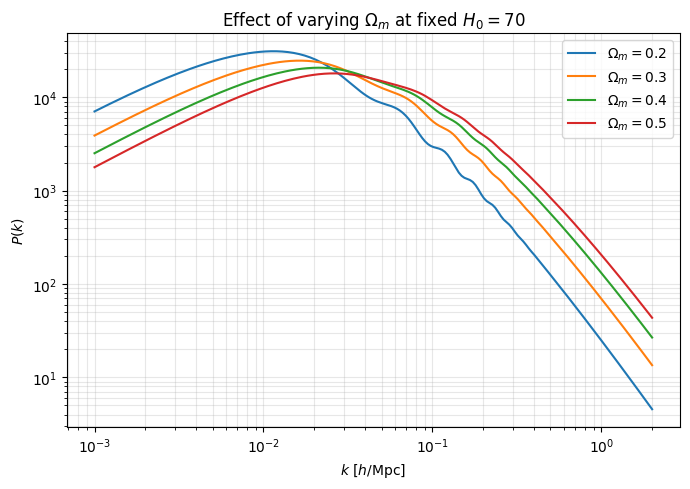

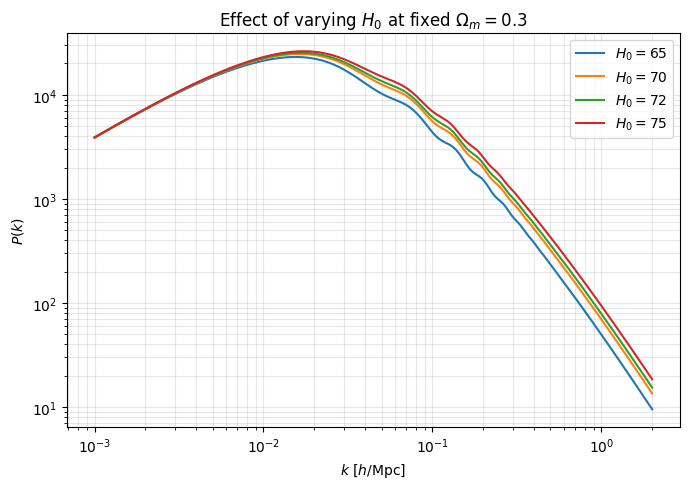

In [1]:
# Uncomment if CAMB is not installed:
# !pip install camb

import numpy as np
import matplotlib.pyplot as plt

try:
    import camb
    from camb import model
    camb_available = True
except ImportError:
    camb_available = False
    print("CAMB is not installed. Run: !pip install camb")

def compute_pk(Omega_m=0.3, H0=70.0, kmax=2.0, nk=200):
    if not camb_available:
        raise ImportError("CAMB is required for Phase 1.")

    # Keep a simple fixed baryon fraction for the comparison.
    omega_b = 0.022
    h = H0 / 100.0
    omega_m = Omega_m * h**2
    omega_c = max(omega_m - omega_b, 1e-5)

    pars = camb.CAMBparams()
    pars.set_cosmology(H0=H0, ombh2=omega_b, omch2=omega_c)
    pars.InitPower.set_params(As=2e-9, ns=0.965)
    pars.set_matter_power(redshifts=[0.0], kmax=kmax)

    results = camb.get_results(pars)
    k, z_out, pk = results.get_matter_power_spectrum(
        minkh=1e-3, maxkh=kmax, npoints=nk
    )
    return k, pk[0]

if camb_available:
    # Vary Omega_m at fixed H0
    plt.figure(figsize=(7, 5))
    for Om in [0.2, 0.3, 0.4, 0.5]:
        k, pk = compute_pk(Omega_m=Om, H0=70.0)
        plt.loglog(k, pk, label=fr"$\Omega_m={Om}$")

    plt.xlabel(r"$k$ [$h$/Mpc]")
    plt.ylabel(r"$P(k)$")
    plt.title(r"Effect of varying $\Omega_m$ at fixed $H_0=70$")
    plt.legend()
    plt.grid(True, which="both", alpha=0.3)
    plt.tight_layout()
    plt.show()

    # Vary H0 at fixed Omega_m
    plt.figure(figsize=(7, 5))
    for H0 in [65, 70, 72, 75]:
        k, pk = compute_pk(Omega_m=0.3, H0=H0)
        plt.loglog(k, pk, label=fr"$H_0={H0}$")

    plt.xlabel(r"$k$ [$h$/Mpc]")
    plt.ylabel(r"$P(k)$")
    plt.title(r"Effect of varying $H_0$ at fixed $\Omega_m=0.3$")
    plt.legend()
    plt.grid(True, which="both", alpha=0.3)
    plt.tight_layout()
    plt.show()

### Phase 1 discussion

The plots should be interpreted by comparing both the overall shape and the position of the turnover. Changing $\Omega_m$ changes the matter content and therefore affects the characteristic matter–radiation equality scale and late-time growth. Changing $H_0$ also changes the mapping between physical densities and scales. The exact visual trend in this assignment should be read directly from the CAMB curves generated by the code above.

## Phase 2 — Neural-network regression

The supplied dataset is loaded from `data/pk_dataset.npz`. The model predicts the two targets, $\Omega_m$ and $H_0$, from the $P(k)$ array.

Because $P(k)$ values span a large dynamic range, I use `log10(P(k))` as the network input and standardize both inputs and targets using statistics calculated from the training subset only.

In [5]:
import numpy as np
from pathlib import Path

data = np.load(Path("data/pk_dataset.npz"))

k = data["k"]
Pk = data["Pk"]
params = data["params"]

print("k shape:", k.shape)
print("Pk shape:", Pk.shape)
print("params shape:", params.shape)

print("First parameter rows:")
print(params[:5])

k shape: (200,)
Pk shape: (200, 200)
params shape: (200, 2)
First parameter rows:
[[ 0.3273956  71.66442903]
 [ 0.29388784 72.83095856]
 [ 0.33585979 70.00444712]
 [ 0.3197368  67.86338502]
 [ 0.25941773 67.08361773]]


In [6]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X = np.log10(np.clip(Pk, 1e-30, None))
y = params

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.10, random_state=42
)

x_scaler = StandardScaler()
y_scaler = StandardScaler()

X_train_scaled = x_scaler.fit_transform(X_train)
X_test_scaled = x_scaler.transform(X_test)

y_train_scaled = y_scaler.fit_transform(y_train)
y_test_scaled = y_scaler.transform(y_test)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

Training samples: 180
Testing samples: 20


In [7]:
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader

torch.manual_seed(42)

X_train_t = torch.tensor(X_train_scaled, dtype=torch.float32)
y_train_t = torch.tensor(y_train_scaled, dtype=torch.float32)
X_test_t = torch.tensor(X_test_scaled, dtype=torch.float32)
y_test_t = torch.tensor(y_test_scaled, dtype=torch.float32)

train_loader = DataLoader(
    TensorDataset(X_train_t, y_train_t),
    batch_size=32,
    shuffle=True,
)

class PowerSpectrumRegressor(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.network = nn.Sequential(
            nn.Linear(input_dim, 128),
            nn.ReLU(),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Linear(64, 2),
        )

    def forward(self, x):
        return self.network(x)

model = PowerSpectrumRegressor(X_train.shape[1])

criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

history = []

for epoch in range(300):
    model.train()
    running_loss = 0.0

    for xb, yb in train_loader:
        optimizer.zero_grad()
        prediction = model(xb)
        loss = criterion(prediction, yb)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * len(xb)

    epoch_loss = running_loss / len(train_loader.dataset)
    history.append(epoch_loss)

    if (epoch + 1) % 50 == 0:
        print(f"Epoch {epoch+1:3d}/300 | train MSE: {epoch_loss:.6f}")

Epoch  50/300 | train MSE: 0.000900
Epoch 100/300 | train MSE: 0.000374
Epoch 150/300 | train MSE: 0.000508
Epoch 200/300 | train MSE: 0.001205
Epoch 250/300 | train MSE: 0.000238
Epoch 300/300 | train MSE: 0.000229


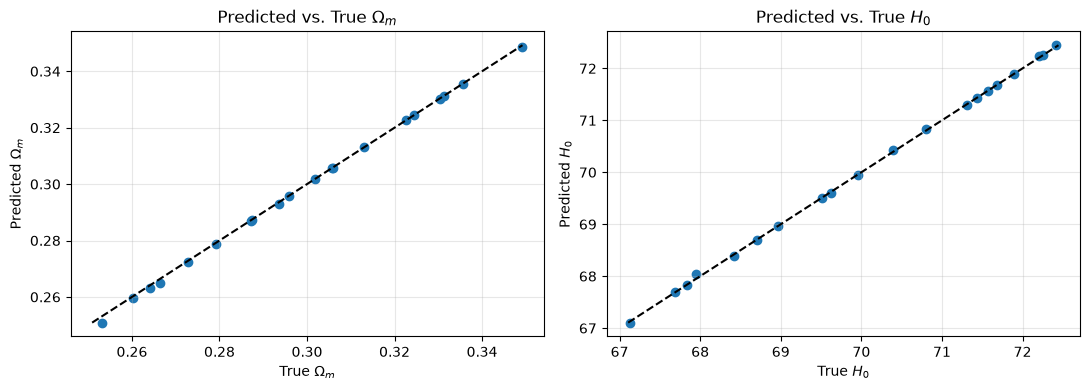

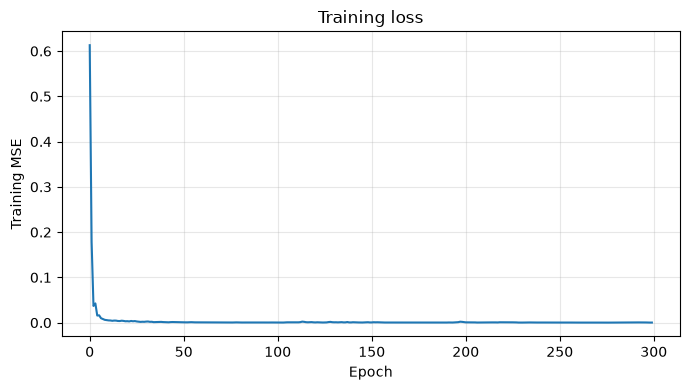

Test RMSE for Omega_m: 0.000697
Test RMSE for H0:      0.028598


In [8]:
model.eval()

with torch.no_grad():
    y_pred_scaled = model(X_test_t).numpy()

y_pred = y_scaler.inverse_transform(y_pred_scaled)

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

labels = [r"$\Omega_m$", r"$H_0$"]
for i, ax in enumerate(axes):
    ax.scatter(y_test[:, i], y_pred[:, i])
    lo = min(y_test[:, i].min(), y_pred[:, i].min())
    hi = max(y_test[:, i].max(), y_pred[:, i].max())
    ax.plot([lo, hi], [lo, hi], "k--")
    ax.set_xlabel(f"True {labels[i]}")
    ax.set_ylabel(f"Predicted {labels[i]}")
    ax.set_title(f"Predicted vs. True {labels[i]}")
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

plt.figure(figsize=(7, 4))
plt.plot(history)
plt.xlabel("Epoch")
plt.ylabel("Training MSE")
plt.title("Training loss")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

rmse = np.sqrt(np.mean((y_pred - y_test)**2, axis=0))
print(f"Test RMSE for Omega_m: {rmse[0]:.6f}")
print(f"Test RMSE for H0:      {rmse[1]:.6f}")